 ## Section 1. Buisiness Understanding 
In this Project we will use 2023 World Bank data to explore if living in a wealthier  nation translates to longer life expectancy for men and woman.  The Word Bank Data includes 2023 data for GDP, GPP Annual Percentage Growth, GDP Per capita of 217 nations.  The World bank data also includes the percentage of men and woman employed in agriculture.  The World Bank data also includes the life expectancy of men and woman past 60.   


__Questions we hope to answer:__
1. Is there a correlation between Gross Domestic Product(GDP), GPD Annual Percentage Grown, or GDP Per Cap and to living longer past 60 years of age?
2. In countries where more men and woman are employed in agriculture, is the life expectancy past 60 lower?
3. Are male and female life expectancy correlated and do woman tend to live longer?
4. Can we use one of the economic variables like GDP or GDP per capita, and Agriculture related features in the 2023 World Bank data to train a linear regression model that predicts the life expectancy of men past 60?  


In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# load Excel File
df = pd.read_excel('WBDATA_10.xlsx')

## Section 2. DATA UNDERSTANDING
First investigation of the data is to look at the data types and info of the data frame.


In [2]:
# look at uploaded datafile
df.head()

,GDP 2023,GDP GROWTH ANNUAL PERCTAGE 2023,GDP PER CAP 2023,AGRICULTURE PERCENT MALE EMPLOYED 2023,AGRICULTURE PERCENT FEMALE EMPLOYED 2023,FEMALE LIFE EXPECTANCY AT 60 IN 2023,MALE LIFE EXPECTANCY AT 60 IN 2023
0,1.720000e+10,2.27,413.76,45.34,47.42,17.53,15.80
1,2.350000e+10,3.94,8575.17,30.80,39.93,24.05,21.86
2,2.480000e+11,4.10,5364.03,10.43,3.18,21.57,19.40
3,NaN,NaN,NaN,NaN,NaN,20.66,17.42
4,3.790000e+09,2.58,46812.45,NaN,NaN,27.78,24.14


In [3]:
# look at the data frame for data type and missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 7 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   GDP 2023                                   200 non-null    float64
 1   GDP GROWTH ANNUAL PERCTAGE 2023            201 non-null    float64
 2   GDP PER CAP 2023                           200 non-null    float64
 3   AGRICULTURE PERCENT MALE EMPLOYED  2023    184 non-null    float64
 4   AGRICULTURE PERCENT FEMALE EMPLOYED  2023  184 non-null    float64
 5   FEMALE LIFE EXPECTANCY AT 60 IN  2023      216 non-null    float64
 6   MALE LIFE EXPECTANCY AT 60 IN 2023         216 non-null    float64
dtypes: float64(7)
memory usage: 12.0 KB



 
__We now have a dataset with 217 entries.__  
- Per the cells above, we see each variable is numeric (float64).
- There are missing values present in several columns.

To better understand the data we will:

- Look at the mean of each column
- Produce a histogram for the different variables.
- Produce the correlation matrix to look for correlations in the dataset.

In [4]:
# generate the mean of each column in our data frame
np.mean(df, axis=0)

GDP 2023                                     5.272652e+11
GDP GROWTH ANNUAL PERCTAGE 2023              3.277711e+00
GDP PER CAP 2023                             2.163406e+04
AGRICULTURE PERCENT MALE EMPLOYED  2023      2.264478e+01
AGRICULTURE PERCENT FEMALE EMPLOYED  2023    2.143935e+01
FEMALE LIFE EXPECTANCY AT 60 IN  2023        2.194079e+01
MALE LIFE EXPECTANCY AT 60 IN 2023           1.871903e+01
dtype: float64

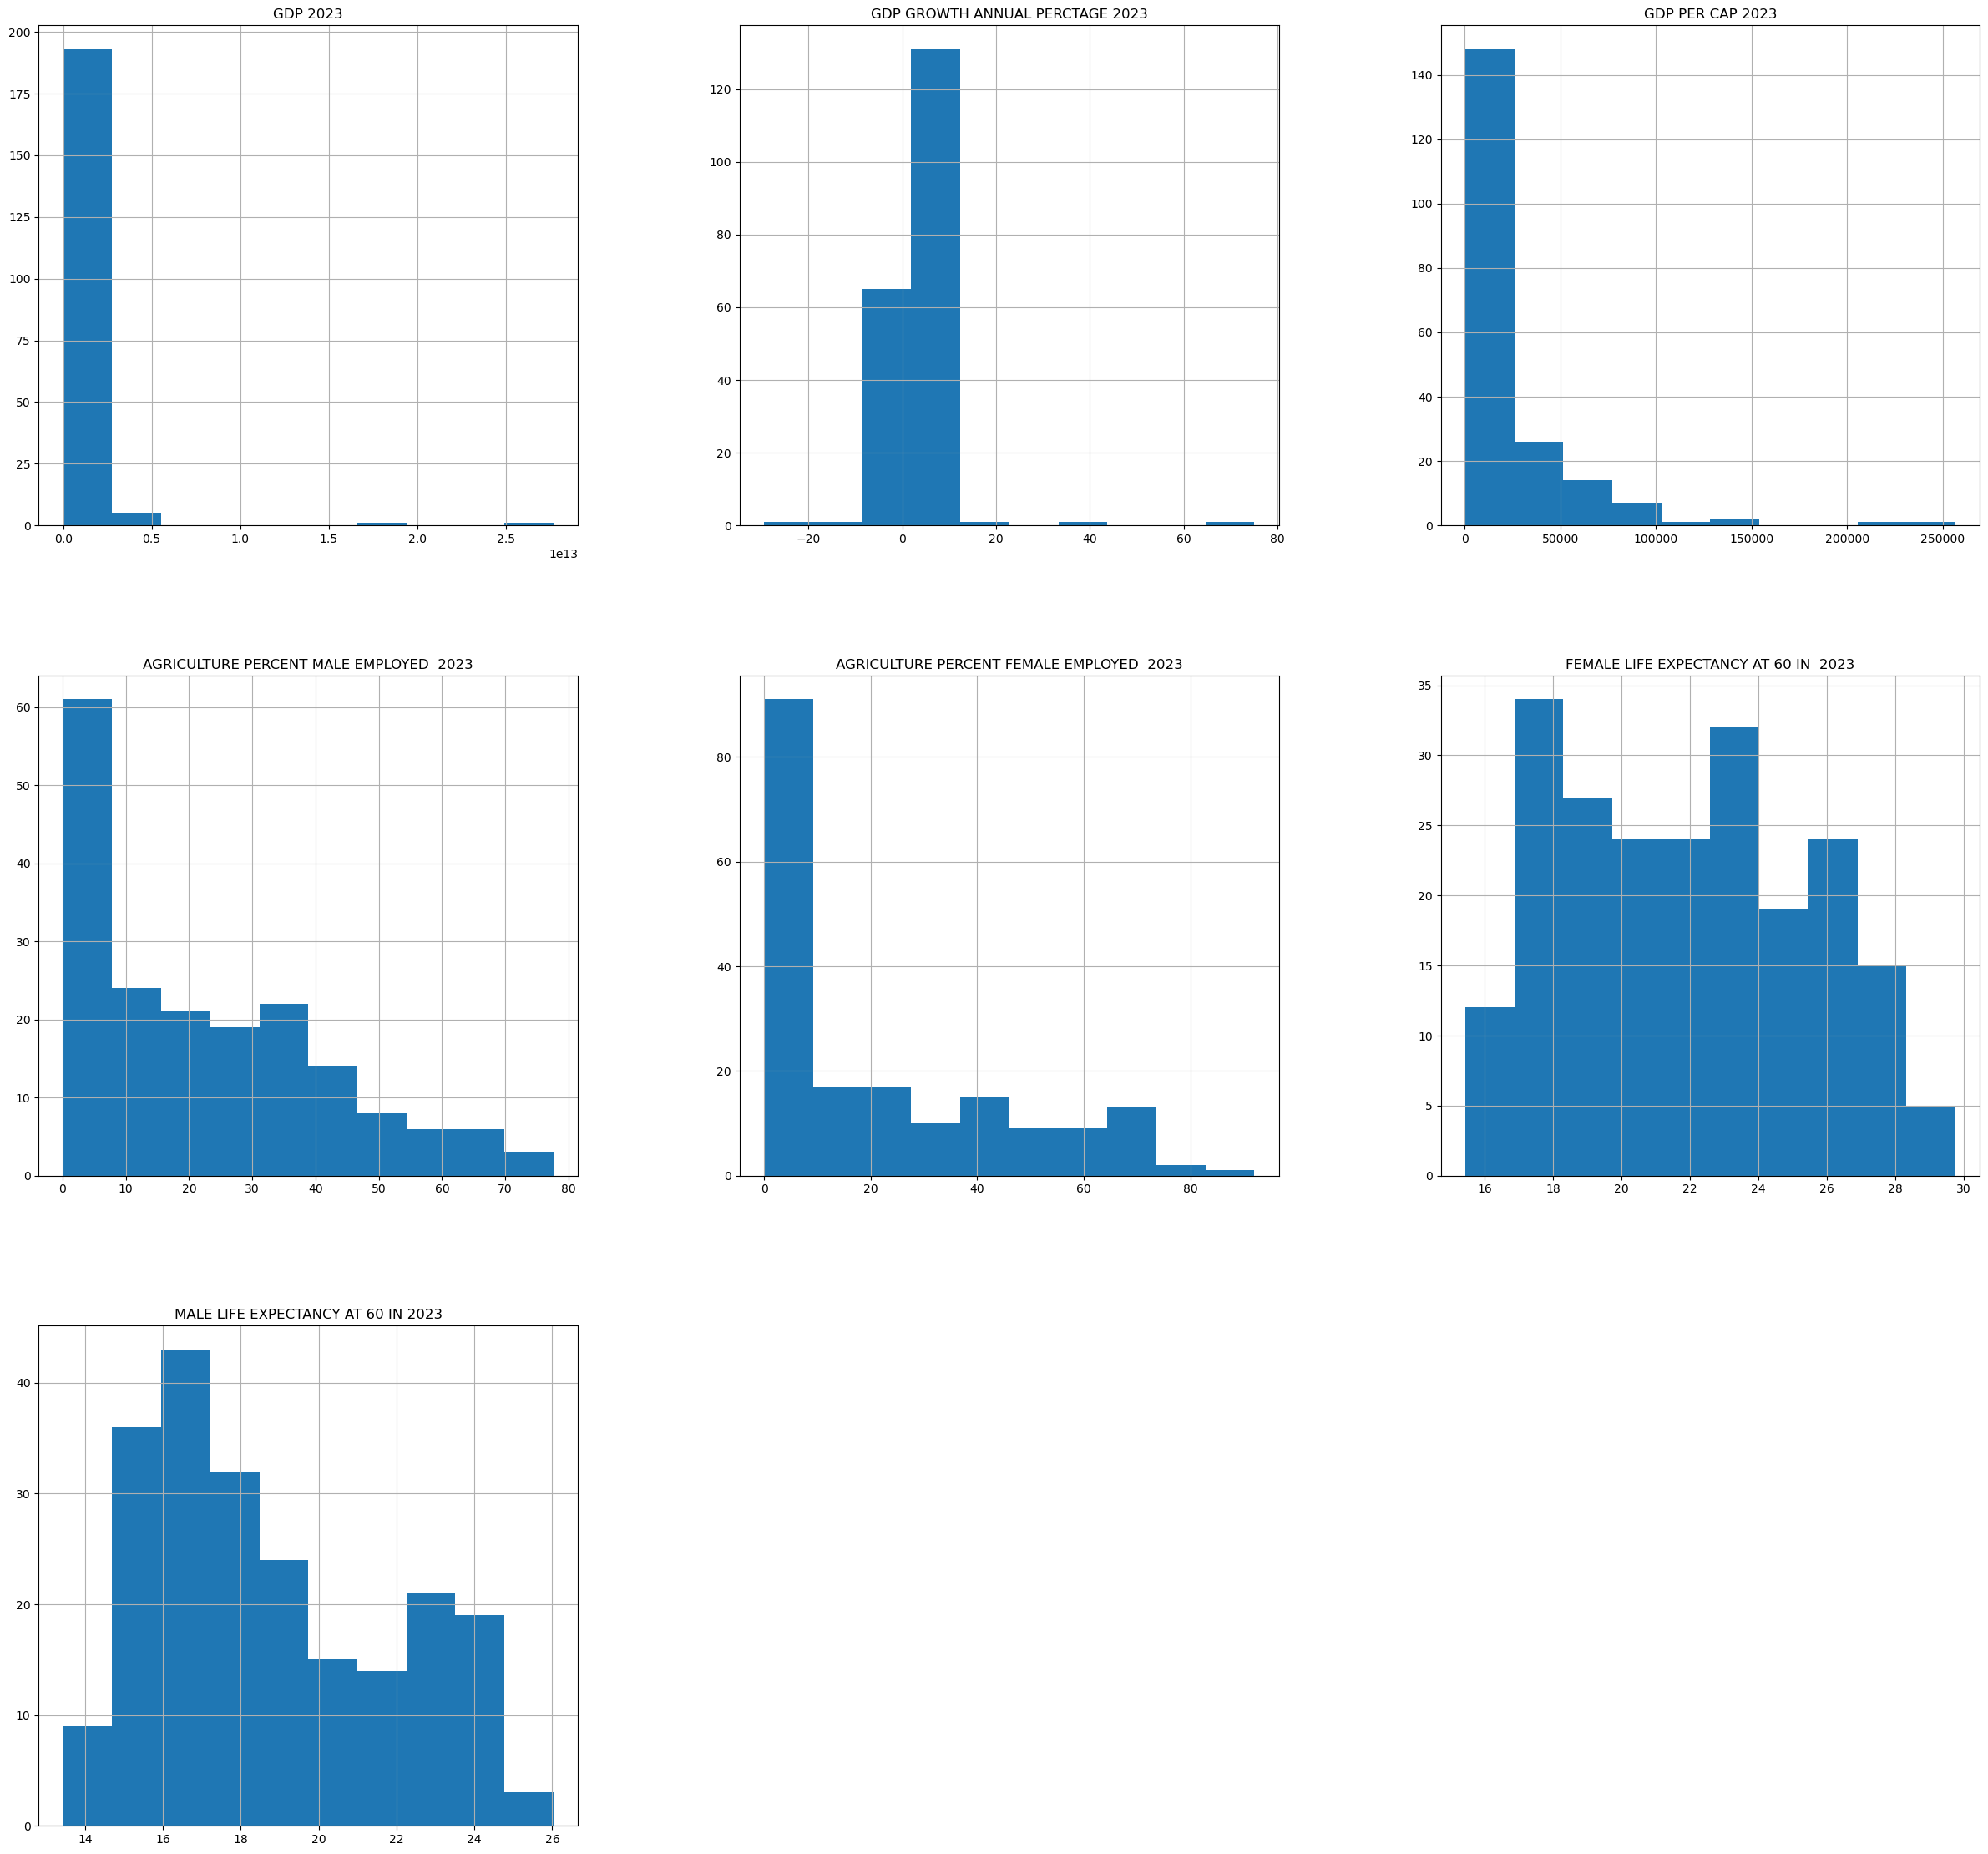

In [5]:
# histograms plots of the features with matplotlib to see their distributions
df.hist(bins=10, figsize=(30, 28))
plt.show()

We see from the histograms that the GDP (Gross Domestic Product) factors tend to be heavily skewed to the right.  This makes sense as most nations are not wealthy.   In a similar fashion we see the factors for percentage of men and woman in aggriculture are heavily skewed to the right.   Again this would be expected as the majority of nations would have substantial aggriculture.   

In [6]:
# Calculate the correlation matrix of the features before plotting
corr_matrix = df.corr()

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

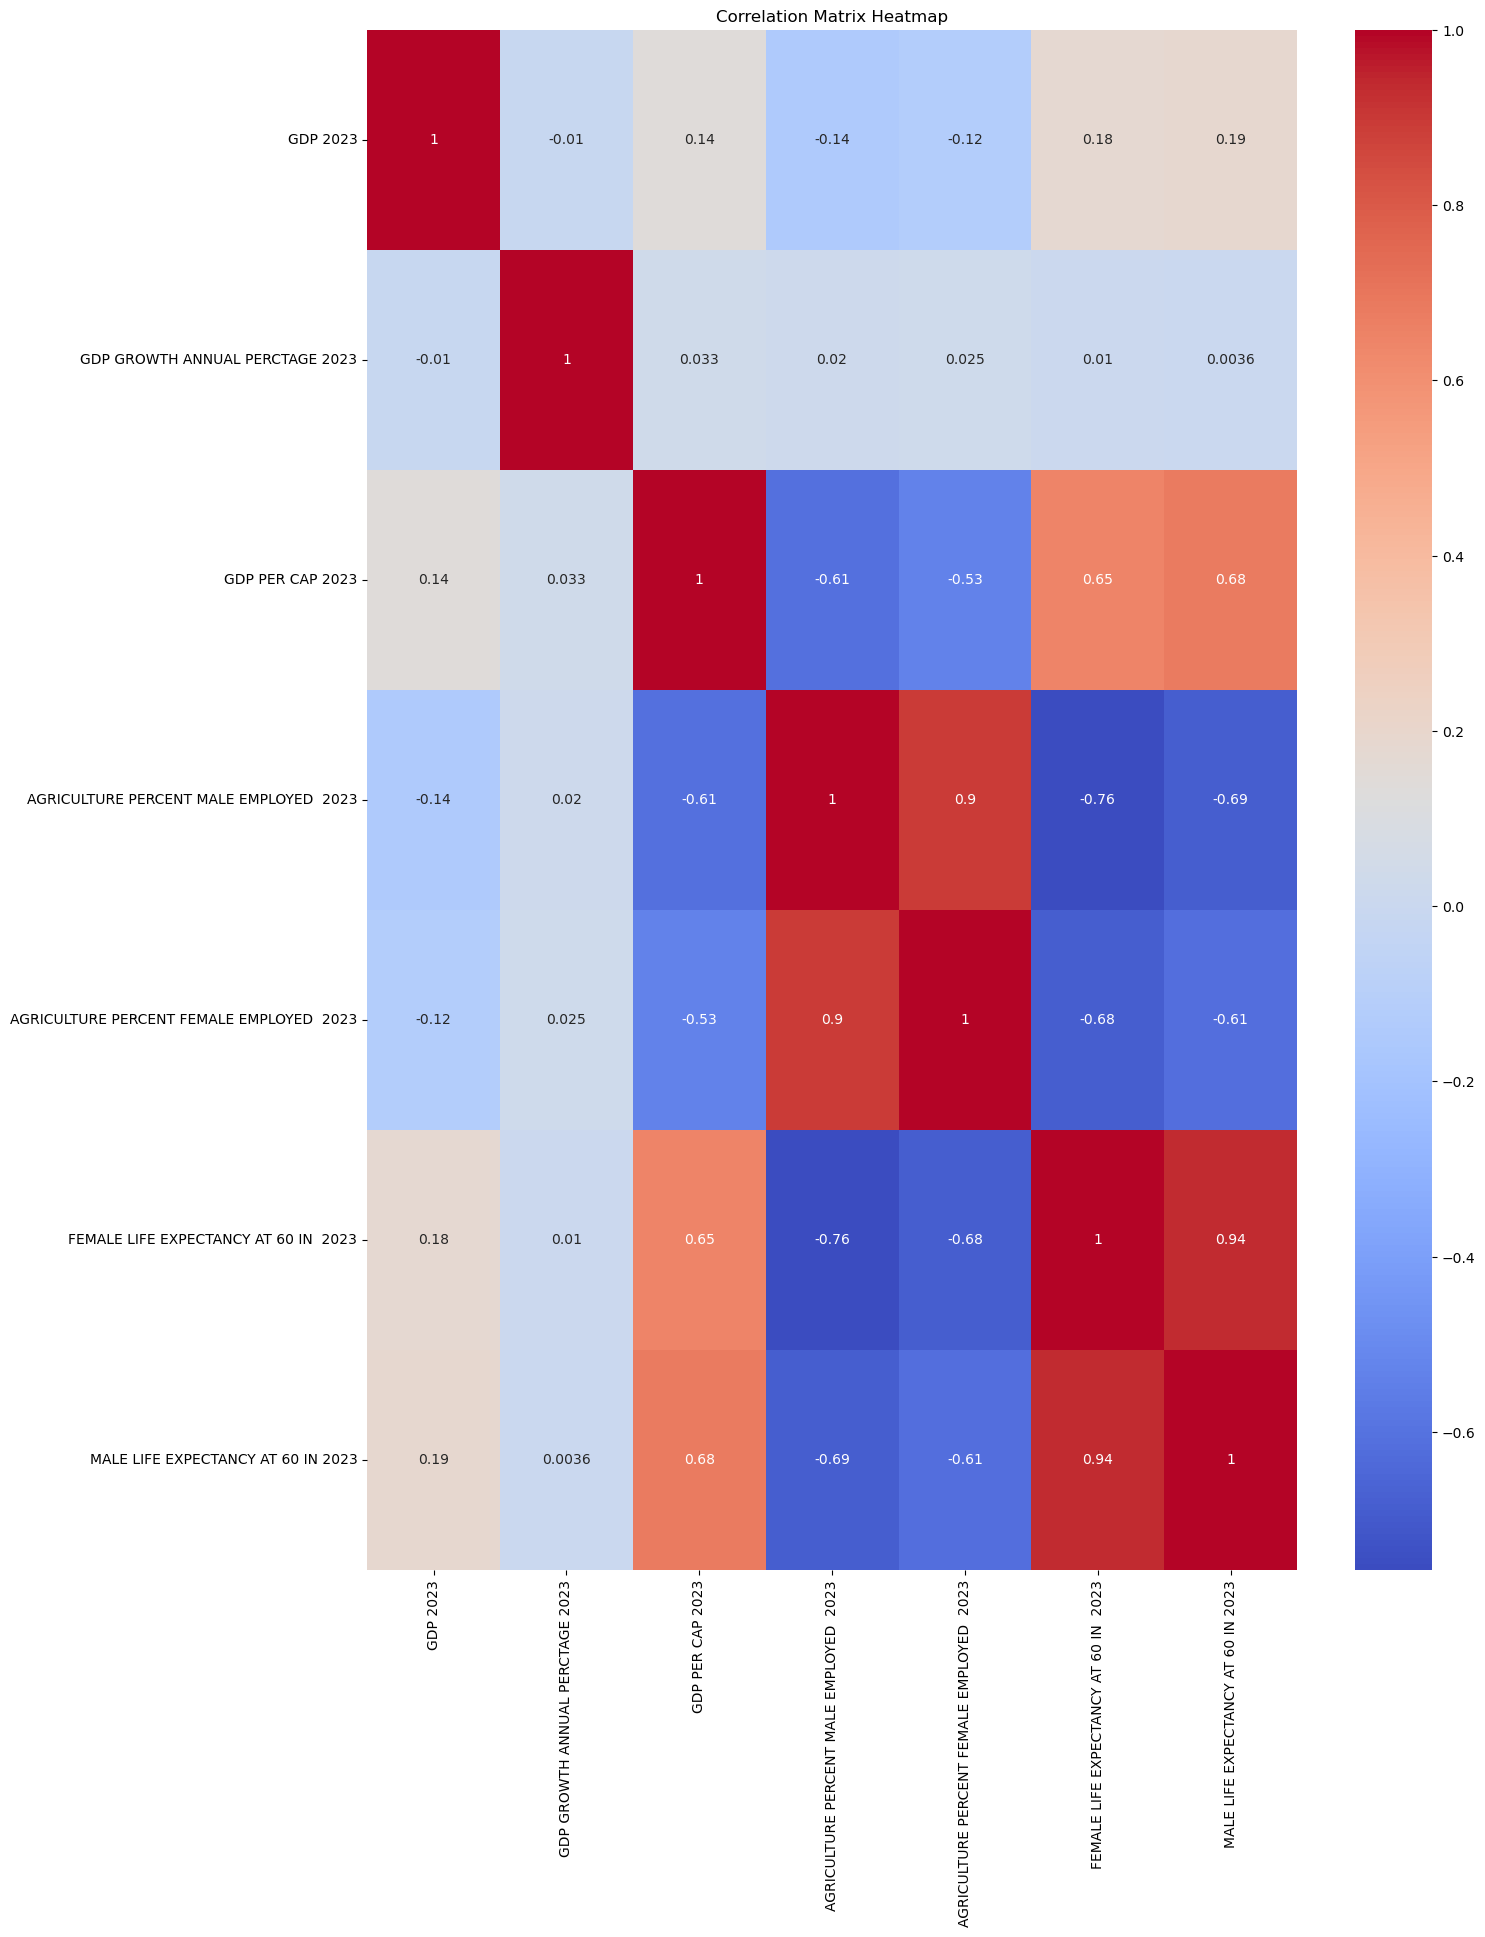

In [7]:
# Plot heatmap of the correlation matrix
plt.figure(figsize=(15, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')

From the Correlation Heat Matrix above we can observe correlations between Aggriculture employment and Life Expectancy Past 60.  
__Of the three different GDP factors, we notice GDP Per Capita shows correlations with the Life Expectancy and Agricultural factors.__  
Below we will sort the GDP correalation matrix values for the three GDP related variables. 

In [8]:
# Correlation Coefficient numbers for GDP Per Cap 2023 in descending order
corr_matrix["GDP PER CAP 2023"].sort_values(ascending=False)

GDP PER CAP 2023                             1.000000
MALE LIFE EXPECTANCY AT 60 IN 2023           0.677791
FEMALE LIFE EXPECTANCY AT 60 IN  2023        0.649086
GDP 2023                                     0.139478
GDP GROWTH ANNUAL PERCTAGE 2023              0.032882
AGRICULTURE PERCENT FEMALE EMPLOYED  2023   -0.531402
AGRICULTURE PERCENT MALE EMPLOYED  2023     -0.606758
Name: GDP PER CAP 2023, dtype: float64

In [9]:
# Generate Correlation Coefficient numbers for GDP 2023 in descending order
corr_matrix["GDP 2023"].sort_values(ascending=False)

GDP 2023                                     1.000000
MALE LIFE EXPECTANCY AT 60 IN 2023           0.187832
FEMALE LIFE EXPECTANCY AT 60 IN  2023        0.180060
GDP PER CAP 2023                             0.139478
GDP GROWTH ANNUAL PERCTAGE 2023             -0.010021
AGRICULTURE PERCENT FEMALE EMPLOYED  2023   -0.119438
AGRICULTURE PERCENT MALE EMPLOYED  2023     -0.140843
Name: GDP 2023, dtype: float64

In [10]:
# Correlation Coefficient numbers for GDP Growth Annual Percentage 2023
corr_matrix["GDP GROWTH ANNUAL PERCTAGE 2023"].sort_values(ascending=False)

GDP GROWTH ANNUAL PERCTAGE 2023              1.000000
GDP PER CAP 2023                             0.032882
AGRICULTURE PERCENT FEMALE EMPLOYED  2023    0.025229
AGRICULTURE PERCENT MALE EMPLOYED  2023      0.020035
FEMALE LIFE EXPECTANCY AT 60 IN  2023        0.010297
MALE LIFE EXPECTANCY AT 60 IN 2023           0.003620
GDP 2023                                    -0.010021
Name: GDP GROWTH ANNUAL PERCTAGE 2023, dtype: float64

__Answer to Question 1:__  We can see from the correlation matrix that only GDP Per Cap 2023 correlates with life expectancy past 60 for men and woman (0.67 and 0.649).
GDP and GPD Annual Growth percentage do not show a good correlation, with both below 0.2 for life exectancy for men or woman.

__Note:__ While not an initial question, it is interesting to observe that GDP PER Capita negatively correlates with the percentage of men and woman employed in agriculture.  Hence countries with richer citizens tend to have less citizens working in agriculture. 

Below we will produce a scatter plot of the different feature pairs to explore the relationships between them.  Given the low correlation of the features "GDP Growth Annual Percentage" and "GDP" to the agriculture and life expectancy features, we not use them in the scatterplot analysis. 

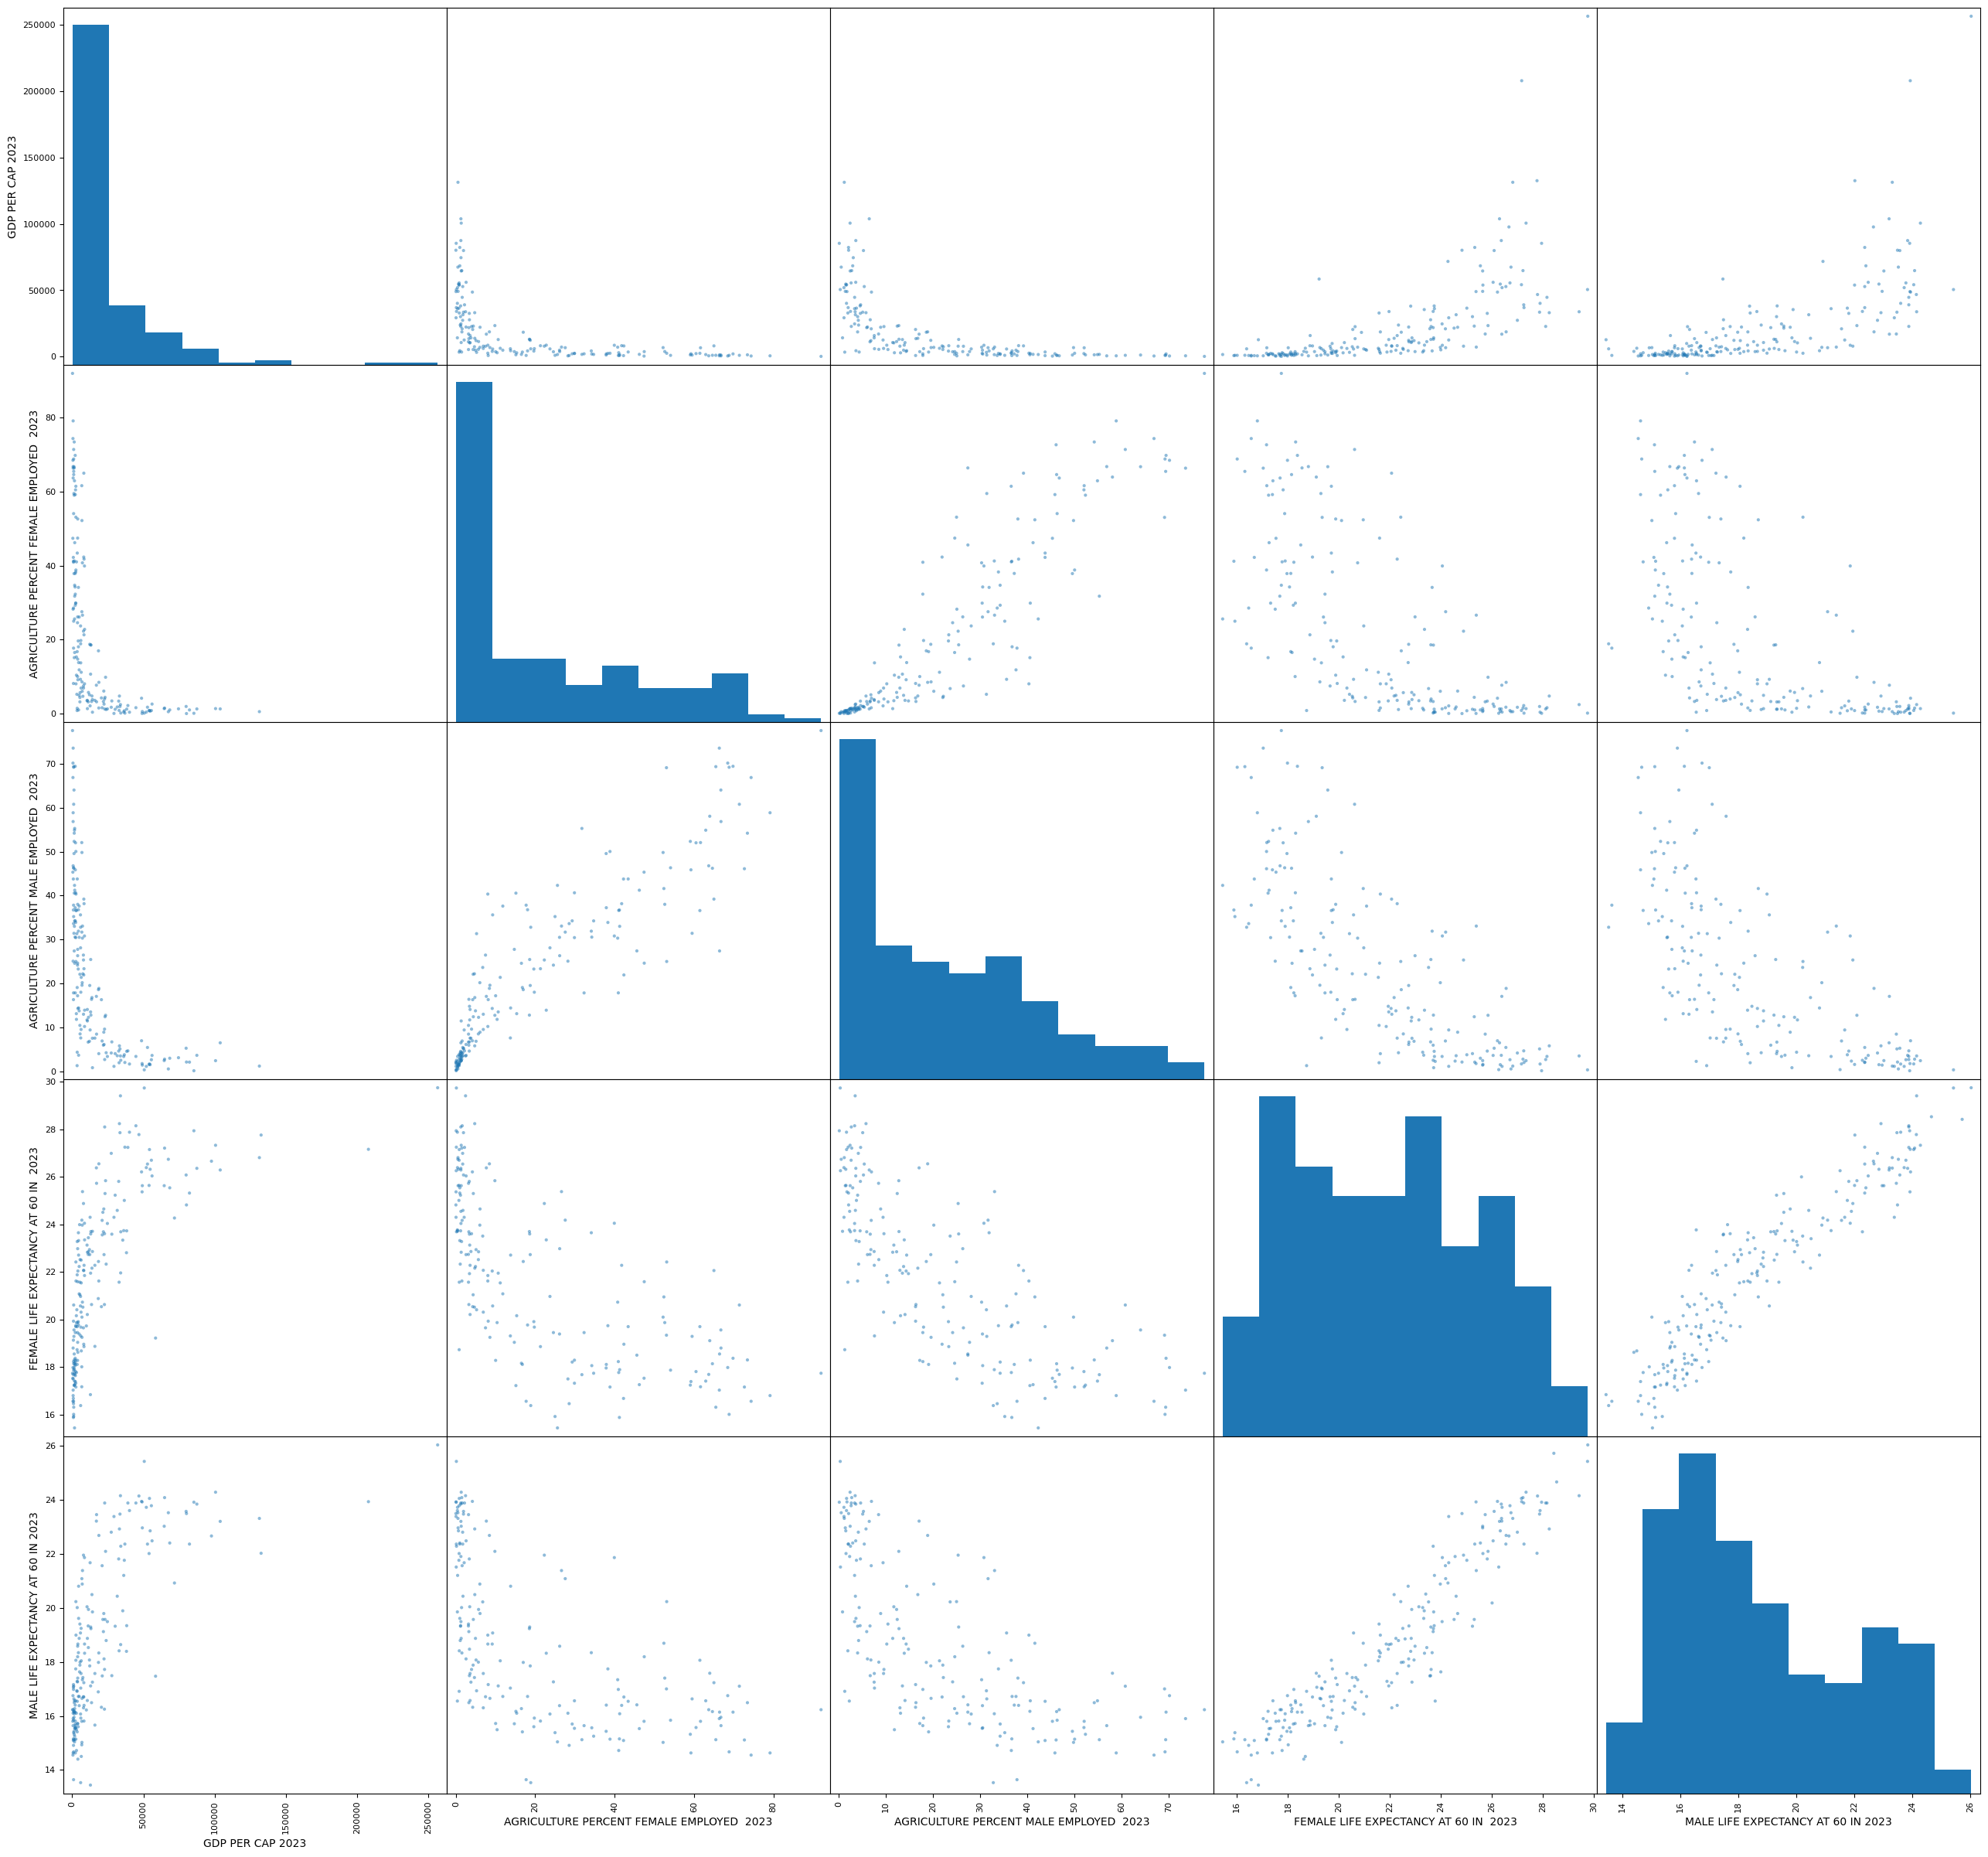

In [11]:
# Plot the most important feature pairs with a scatter plot
from pandas.plotting import scatter_matrix
feature = ["GDP PER CAP 2023", "AGRICULTURE PERCENT FEMALE EMPLOYED  2023",
           "AGRICULTURE PERCENT MALE EMPLOYED  2023",
           "FEMALE LIFE EXPECTANCY AT 60 IN  2023",
           "MALE LIFE EXPECTANCY AT 60 IN 2023"]
scatter_matrix(df[feature], figsize=(32, 30))
plt.show()

After looking at the graphs above we investigate 5 graphs of interest.  These are GDP per capita vs male and female life expectancy followed by life expectancy and percentage of men and woman in agriculture graphs.  

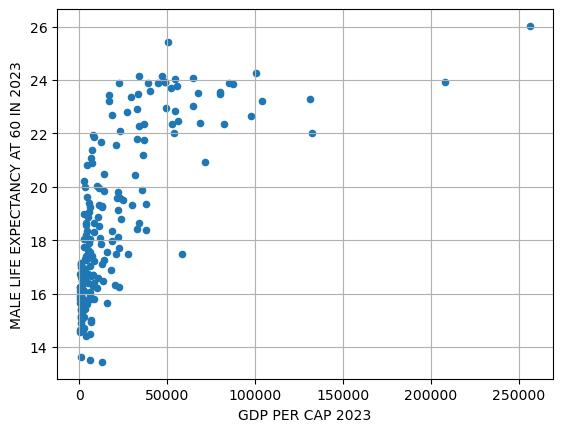

In [12]:
# Choose the most important feature and plot it against the target
df.plot(kind="scatter", x="GDP PER CAP 2023",
        y="MALE LIFE EXPECTANCY AT 60 IN 2023", grid=True)
plt.show()

From 0 to 50,000 GDP Per Capita we see a steady increase in Male Life Expectancy past 60.  Past 50,000 GDP Per Capita there is little increase in Male life expectancy after age 60.

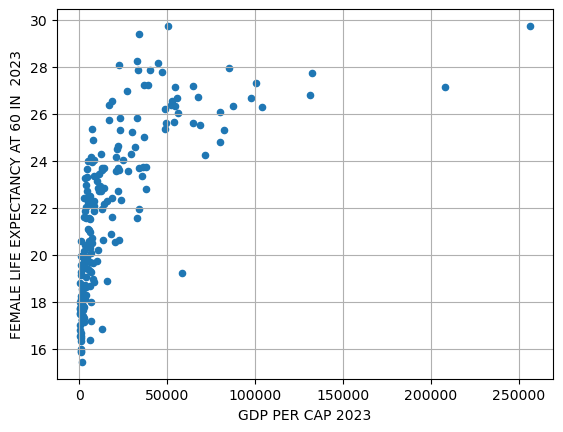

In [13]:
# Choose the most important feature and plot it against the target
df.plot(kind="scatter", x="GDP PER CAP 2023",
        y="FEMALE LIFE EXPECTANCY AT 60 IN  2023", grid=True)
plt.show()

From 0 to 50,000 GDP Per Capita we see a steady increase in Female Life Expectancy past 60.  Past 50,000 GDP Per Capita there is little increase in Male life expectancy after age 60.

__Below we produce a new scatterplot that includes both the Female and Male data. This graph will be used in our blog and allow us to compare the life expectancy past 60 for men and woman, and the effect of GDP Per Capita.   The graph will also allow us to visualize and compare the male and female data__

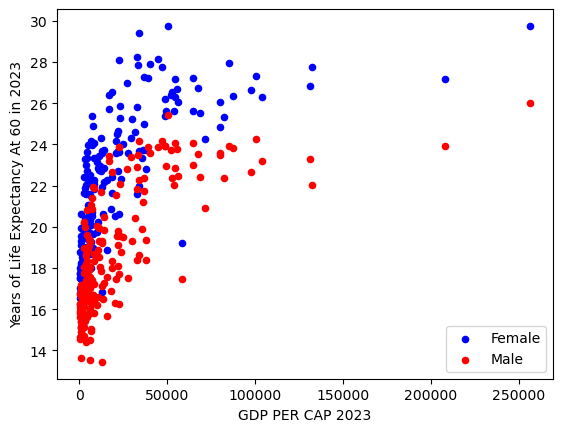

In [14]:
# WE choose the most important features and plot against the target.
# This new scatter plot will show data for Men and Woman on one graph.
ax = df.plot(
    kind="scatter",
    x="GDP PER CAP 2023",
    y="FEMALE LIFE EXPECTANCY AT 60 IN  2023",
    color="blue",
    label="Female"
)
df.plot(
    kind="scatter",
    x="GDP PER CAP 2023",
    y="MALE LIFE EXPECTANCY AT 60 IN 2023",
    color="red",
    label="Male",
    ax=ax
)
# We set the label for the Y Axis
ax.set_ylabel("Years of Life Expectancy At 60 in 2023")
plt.show()

We can see from the graph above that both male and females expect longer life expectancy as GDP Per Capita increases.   
A point to note is that the male life expectancy appears to be lower than female life expectancy.

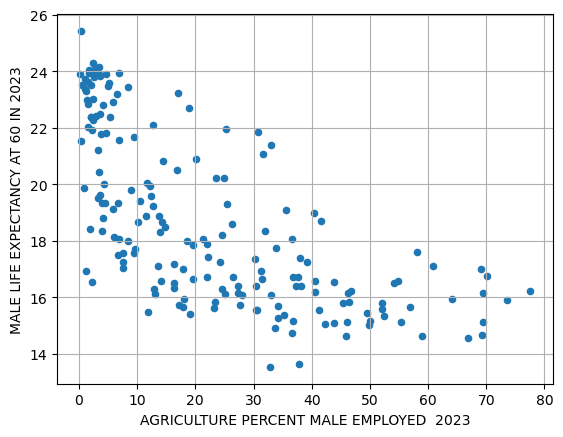

In [15]:
# Choose the most important feature and plot it against the target
df.plot(kind="scatter", y="MALE LIFE EXPECTANCY AT 60 IN 2023",
        x="AGRICULTURE PERCENT MALE EMPLOYED  2023", grid=True)
plt.show()

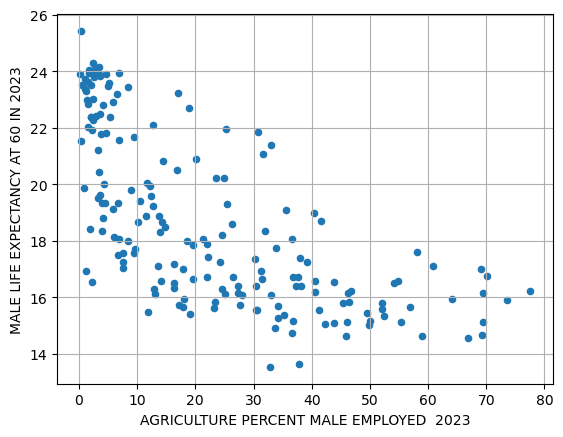

In [16]:
# Choose the most important feature and plot it against the target
df.plot(kind="scatter", y="MALE LIFE EXPECTANCY AT 60 IN 2023",
        x="AGRICULTURE PERCENT MALE EMPLOYED  2023", grid=True)
plt.show()

We see that men live longest in countries in which there is very little male employment in agriculture.

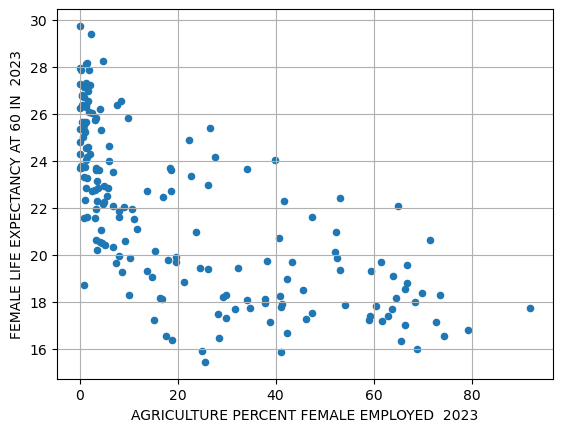

In [17]:
# Choose the most important feature and plot it against the target
df.plot(kind="scatter", y="FEMALE LIFE EXPECTANCY AT 60 IN  2023",
        x="AGRICULTURE PERCENT FEMALE EMPLOYED  2023", grid=True)
plt.show()

__Below we produce a new scatterplot that includes both the Female and Male data.   This graph will be used in our blog and allow us to
compare the life expectancy past 60 for men and woman, when employed in agriculture.__

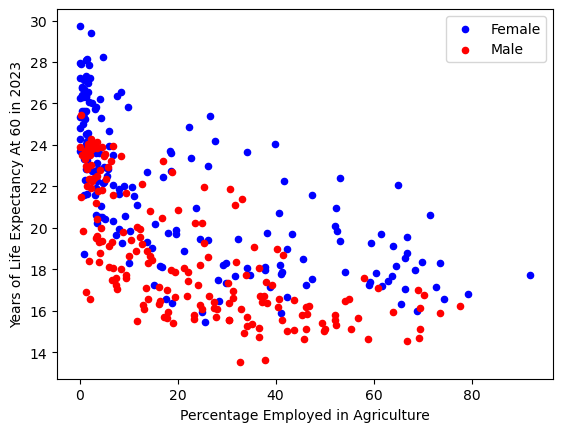

In [18]:
# WE choose the most important features and plot against the target.
# This new scatter plot will show data for Men and Woman on one graph.
ax = df.plot(
    kind="scatter",
    x="AGRICULTURE PERCENT FEMALE EMPLOYED  2023",
    y="FEMALE LIFE EXPECTANCY AT 60 IN  2023",
    color="blue",
    label="Female"
)
df.plot(
    kind="scatter",
    x="AGRICULTURE PERCENT MALE EMPLOYED  2023",
    y="MALE LIFE EXPECTANCY AT 60 IN 2023",
    color="red",
    label="Male",
    ax=ax
)
# We set our ylabel and xlabel for the new graph
ax.set_ylabel("Years of Life Expectancy At 60 in 2023")
ax.set_xlabel("Percentage Employed in Agriculture")
plt.show()

We see that male and females live longest in countries in which there is very little employment in agriculture.   T

__ANSWER to Question 2:__   We can see that countries in which men and woman have more employment in agriculture relates to lower life expectancy past 60.  Also, we can note that female life expectancy trends higher than males. 

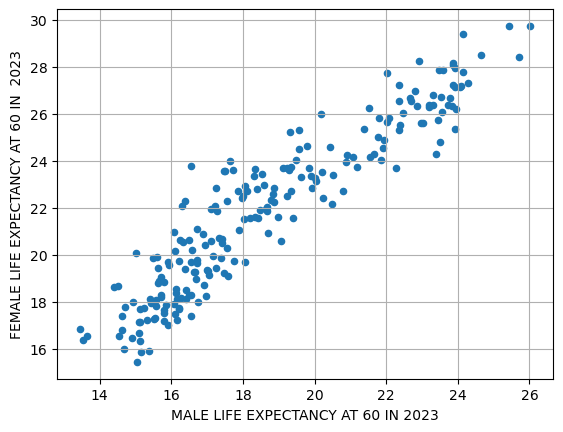

In [19]:
# Choose the most important feature and plot it against the target
df.plot(kind="scatter", y="FEMALE LIFE EXPECTANCY AT 60 IN  2023",
        x="MALE LIFE EXPECTANCY AT 60 IN 2023", grid=True)
plt.show()

__Answer to Question 3__ We see a strong correalation between Male Life Expectancy past 60 and Female Life Expectancy past 60!   Woman tend to live longer compared to men.  



## Section 3 DATA Preparation

NOW, let us build a regression model to see if we can predict Male Life Expectancy Past 60 using the features GDP Per Capita, Percentage of Males employed in Agriculture, Percentage of Females employed in Agriculture.  

__First we must clean the data, removing rows if a missing value is found in a feature or target.__   This is because "sklearn.linear_model.LinearRegression" will not run with missing values.  When df.info() was run earlier we could observe missing values in several columns of the datafile. 

__In the cell below we will make Male Life Expectancy at 60 our Y variable.  X will contain the other features minus Male Life Expectancy Past 60 and Female Life Expectancy Past 60.__

In [20]:
# Drops rows only if missing values are in 'features' or 'target'
df_clean = df.dropna(subset=['GDP PER CAP 2023',
                             'MALE LIFE EXPECTANCY AT 60 IN 2023',
                             'AGRICULTURE PERCENT FEMALE EMPLOYED  2023',
                             'AGRICULTURE PERCENT MALE EMPLOYED  2023'])
X = df_clean[['GDP PER CAP 2023', 'AGRICULTURE PERCENT FEMALE EMPLOYED  2023',
              'AGRICULTURE PERCENT MALE EMPLOYED  2023']]
y = df_clean[['MALE LIFE EXPECTANCY AT 60 IN 2023']]

In [21]:
# check the y values
y

,MALE LIFE EXPECTANCY AT 60 IN 2023
0,15.80
1,21.86
2,19.40
5,15.57
7,19.85
...,...
208,16.10
209,16.54
211,18.34
215,15.32


In [22]:
# Check the X matrix with are features
X

,GDP PER CAP 2023,AGRICULTURE PERCENT FEMALE EMPLOYED 2023,AGRICULTURE PERCENT MALE EMPLOYED 2023
0,413.76,47.42,45.34
1,8575.17,39.93,30.80
2,5364.03,3.18,10.43
5,2309.53,60.52,52.03
7,14187.48,0.38,0.79
...,...,...,...
208,2878.97,15.33,13.10
209,3515.24,43.42,43.79
211,4323.35,34.13,31.90
215,1330.73,59.08,52.35


WE observe the number of rows for X and y match and there is not expected missing values.   

## Section 4: Modeling

Now were will produce a linear regresson model using sklearn. 

In [23]:
# import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
# Check the X and y shape match
print(X.shape, y.shape)

(173, 3) (173, 1)


In [24]:
# Train Test Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [25]:
# we fit our regression model
mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

## Section 5: Evaluation

Now we will predict and score our model.  An r-square and root mean square error will be obtained to evalute the regresson model's performance.

In [26]:
# we now predict and score our model.
mlr_preds = mlr.predict(X_test)
mlr_r2 = mlr.score(X_test, y_test)
mlr_rmse = root_mean_squared_error(y_test, mlr_preds)
# print the r square and RMSE for the fitted model.
print(f'The r^2 is {mlr_r2} and the RMSE is {mlr_rmse}')

The r^2 is 0.6769544917637025 and the RMSE is 1.7735676954343316


__The model produces an r-square of 0.677 coupled with an RMSE of 1.77 years.__  

__This is acceptable result for a well fitting model.__

__Answer to Question 4:__ We can now predict male life expectancy past 60 using GDP per capita and percentage of men and woman employed in agriculture.

  

In [27]:
print(mlr.coef_.shape)

(1, 3)


## Section 6: Deployment

To deploy and use the model, __a custom function is generated.__

We define a custom function below that will input the GDP Per Capita, Percentage of Females and Males empolyed in Agriculture and give a prediction for male life expectancy past 60.  This custom function can be used to forecast Male Life Expectancy.  So for example if a countries economics change over a time we can predict when male life expectancy will increase or decrease.

In [28]:
# create custom function that inputs X values for our model
def Male_Life_Exp_Forecast(mlr, GDP_PerCap, Female_Agriculture_Percentage,
                           Male_Agricultre_Percentage):
    # Create a one-row DataFrame with correct column names
    X_new = pd.DataFrame(
        [[GDP_PerCap, Female_Agriculture_Percentage,
          Male_Agricultre_Percentage]],
        columns=['GDP PER CAP 2023',
                 'AGRICULTURE PERCENT FEMALE EMPLOYED  2023',
                 'AGRICULTURE PERCENT MALE EMPLOYED  2023']
    )
    # Predict
    prediction = mlr.predict(X_new)
    # Return a single value (not an array)
    return prediction[0]

__Let us use our custom function to forecast the life expectancy of Males in the US past 60 years of age.__  The forcasted GDP Per Capita for the US in 2026 is $94430.  There are currently 44% of US females and 56% of US males employed in the agriculture.  We can place these values into our fitted model to obtain an estimate of male life expectancy past 60.

In [29]:
# We use our custom function function and store the prediction in result.
result = Male_Life_Exp_Forecast(mlr, 94430, 44, 56)
# Print the prediction of our model
print(f"The male life expectancy past age 60 is {result} years.")

The male life expectancy past age 60 is [21.27781393] years.


__Our model predicts the male life expectancy in the US past 60, using the 2026 predictions, is 21.277 years.__
